# EXPERIMENT 1 NOTEBOOK: BASELINE

### Imports

In [1]:
import logging; logging.basicConfig(level=logging.INFO)
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import ltn
import pandas as pd


### Data Loading

In [2]:
# Data loading
df = pd.read_csv("data/height_weight_train.csv")  
df = df.sample(frac=1)  

df.head(5)


,height_m,weight
54,1.939133,171.705276
1,1.754536,154.290723
260,1.422409,124.248760
82,1.828758,161.399835
41,1.551069,134.827282


In [3]:
# Only one feature: height
x = df[['height_m']].astype(np.float32)

# Target: weight
y = df[['weight']].astype(np.float32)

# Dataset train/test equal to the original
batch_size = 128
split = int(0.8 * len(df))

x_train, y_train = x[:split], y[:split]
x_test,  y_test  = x[split:], y[split:]

ds_train = tf.data.Dataset.from_tensor_slices((x[:split], y[:split])).batch(batch_size)
ds_test  = tf.data.Dataset.from_tensor_slices((x[split:], y[split:])).batch(batch_size)


## Knowledge Base

#### Model and axioms predicates

In [4]:
# LTN MLP model with 1D entry
model_f = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(8, activation="elu"),
    tf.keras.layers.Dense(8, activation="elu"),
    tf.keras.layers.Dense(1)   # sortida escalar
])

# LTN Function that wraps the model
f = ltn.Function(model_f)

In [5]:
# Regression predicate with robust equalty (exp)
eq = ltn.Predicate.Lambda(
    lambda args: tf.exp(-0.01 * tf.abs(args[0] - args[1]))
)


### Logical operators

We use the classical Product real Logic configuration.

In [6]:
Not = ltn.Wrapper_Connective(ltn.fuzzy_ops.Not_Std())
And = ltn.Wrapper_Connective(ltn.fuzzy_ops.And_Prod())
Or = ltn.Wrapper_Connective(ltn.fuzzy_ops.Or_ProbSum())
Implies = ltn.Wrapper_Connective(ltn.fuzzy_ops.Implies_Reichenbach())
Forall = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMeanError(p=4), semantics="forall")
Exists = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMean(p=2), semantics="exists")


#### Regression axiom

In [7]:
@tf.function
def axioms(x_data, y_data):
    x_var = ltn.Variable("x", x_data)
    y_var = ltn.Variable("y", y_data)
    return Forall(ltn.diag(x_var, y_var), eq([f(x_var), y_var])).tensor


In [8]:
for x_batch, y_batch in ds_test:
    print("Initial sat level %.5f" % axioms(x_batch, y_batch))
    break

metrics_dict = {
    'train_sat': tf.keras.metrics.Mean(name='train_sat'),
    'test_sat': tf.keras.metrics.Mean(name='test_sat'),
    'train_accuracy': tf.keras.metrics.RootMeanSquaredError(name="train_accuracy"),
    'test_accuracy': tf.keras.metrics.RootMeanSquaredError(name="test_accuracy")
}

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)


Initial sat level 0.22593


## Training

In [9]:
@tf.function
def train_step(x, y):
    with tf.GradientTape() as tape:
        sat = axioms(x, y)
        loss = 1. - sat
    gradients = tape.gradient(loss, f.trainable_variables)
    optimizer.apply_gradients(zip(gradients, f.trainable_variables))
    sat = axioms(x, y)
    metrics_dict['train_sat'](sat)
    metrics_dict['train_accuracy'](y, f.model(x))

@tf.function
def test_step(x, y):
    sat = axioms(x, y)
    metrics_dict['test_sat'](sat)
    metrics_dict['test_accuracy'](y, f.model(x))


In [10]:
import commons

EPOCHS = 1500

commons.train(
    EPOCHS,
    metrics_dict,
    ds_train,
    ds_test,
    train_step,
    test_step,
    csv_path="regression_results.csv",
    track_metrics=50
)


Epoch 0, train_sat: 0.2271, test_sat: 0.2260, train_accuracy: 149.3932, test_accuracy: 149.8866
Epoch 50, train_sat: 0.2291, test_sat: 0.2281, train_accuracy: 148.4653, test_accuracy: 148.9562
Epoch 100, train_sat: 0.2314, test_sat: 0.2304, train_accuracy: 147.4498, test_accuracy: 147.9368
Epoch 150, train_sat: 0.2342, test_sat: 0.2331, train_accuracy: 146.2520, test_accuracy: 146.7349
Epoch 200, train_sat: 0.2375, test_sat: 0.2364, train_accuracy: 144.8208, test_accuracy: 145.2997
Epoch 250, train_sat: 0.2414, test_sat: 0.2403, train_accuracy: 143.1718, test_accuracy: 143.6466
Epoch 300, train_sat: 0.2460, test_sat: 0.2449, train_accuracy: 141.2581, test_accuracy: 141.7279
Epoch 350, train_sat: 0.2514, test_sat: 0.2503, train_accuracy: 139.0428, test_accuracy: 139.5065
Epoch 400, train_sat: 0.2578, test_sat: 0.2566, train_accuracy: 136.5136, test_accuracy: 136.9701
Epoch 450, train_sat: 0.2651, test_sat: 0.2640, train_accuracy: 133.6564, test_accuracy: 134.1044
Epoch 500, train_sat: 0

## Predictions and results

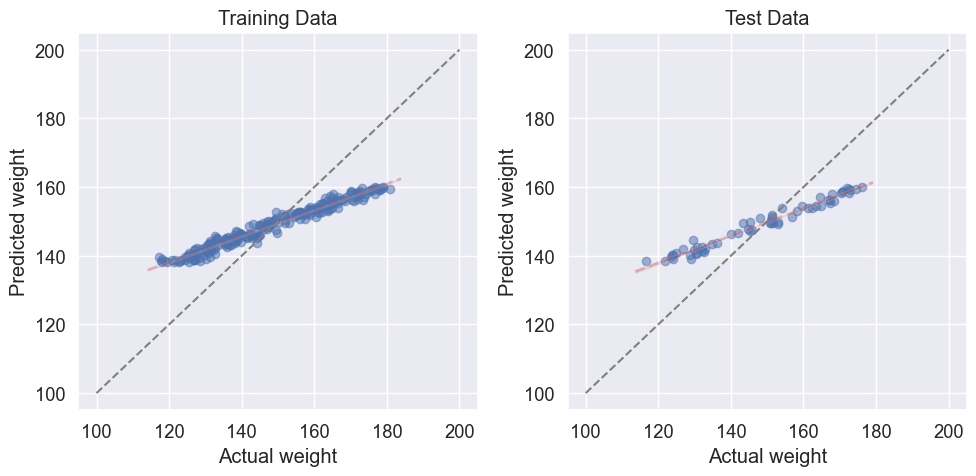

In [11]:
import seaborn as sns
sns.set(font_scale=1.2)

fig, axs = plt.subplots(1,2,figsize=(10,5))

# TRAIN
ax = axs[0]
data = {'y_pred':[], 'y_true':[]}
for x_batch, y_batch in ds_train:
    data['y_pred'].extend(f.model(x_batch)[:,0].numpy())
    data['y_true'].extend(y_batch[:,0].numpy())
df_plot = pd.DataFrame(data, columns=['y_pred','y_true'])

sns.regplot(x="y_true", y="y_pred", data=df_plot, ax=ax, truncate=False,
            scatter_kws={'alpha':0.5},
            line_kws={'color':'r','alpha':0.3,'linestyle':'--','linewidth':2})

ax.plot([100,200],[100,200],color="gray",linestyle="--")
ax.set_xlabel("Actual weight")
ax.set_ylabel("Predicted weight")
ax.set_title("Training Data")

# TEST
ax = axs[1]
data = {'y_pred':[], 'y_true':[]}
for x_batch, y_batch in ds_test:
    data['y_pred'].extend(f.model(x_batch)[:,0].numpy())
    data['y_true'].extend(y_batch[:,0].numpy())
df_plot = pd.DataFrame(data, columns=['y_pred','y_true'])

sns.regplot(x="y_true", y="y_pred", data=df_plot, ax=ax, truncate=False,
            scatter_kws={'alpha':0.5},
            line_kws={'color':'r','alpha':0.3,'linestyle':'--','linewidth':2})

ax.plot([100,200],[100,200],color="gray",linestyle="--")
ax.set_xlabel("Actual weight")
ax.set_ylabel("Predicted weight")
ax.set_title("Test Data")

plt.tight_layout()
plt.show()


In [12]:
print("Train batches:", len(list(ds_train)))
print("Test batches:", len(list(ds_test)))

for x_b, y_b in ds_train.take(1):
    print("Batch shapes:", x_b.shape, y_b.shape)


Train batches: 2
Test batches: 1
Batch shapes: (128, 1) (128, 1)


In [13]:
for x_b, y_b in ds_train.take(1):
    print("x_b:", x_b.shape)
    print("y_b:", y_b.shape)


x_b: (128, 1)
y_b: (128, 1)


In [14]:
for x_b, y_b in ds_train.take(1):
    print("Pred shape:", f.model(x_b).shape)


Pred shape: (128, 1)


TRAIN df_plot head:
       y_true      y_pred
0  171.705276  158.128799
1  154.290726  151.281616
2  124.248756  138.800659
3  161.399841  154.040878
4  134.827286  143.665390
TRAIN df_plot length: 240
TEST df_plot head:
       y_true      y_pred
0  123.863083  140.173615
1  132.701096  141.078598
2  150.932465  150.269394
3  164.532425  157.172684
4  145.260132  149.912125
TEST df_plot length: 60


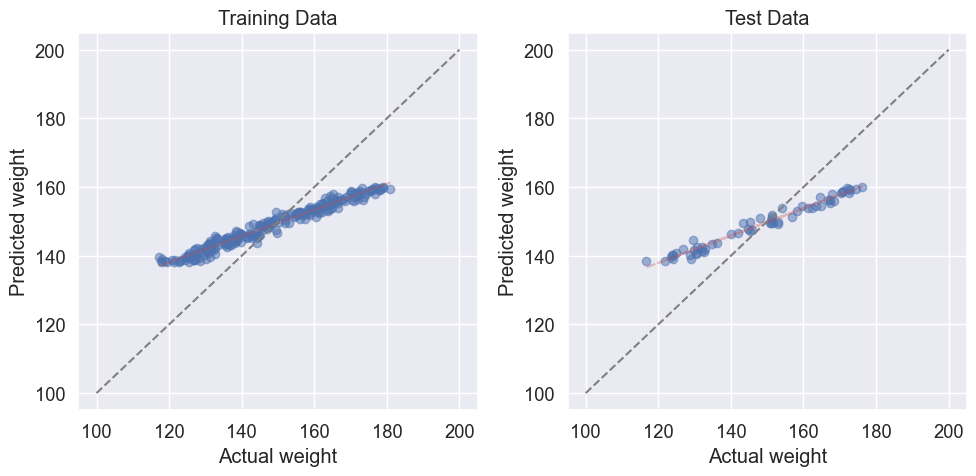

In [15]:
import seaborn as sns
sns.set(font_scale=1.2)

fig, axs = plt.subplots(1,2,figsize=(10,5))

# ---------------------------
# TRAIN
# ---------------------------
ax = axs[0]
y_pred = []
y_true = []

for x_batch, y_batch in ds_train:
    preds = f.model(x_batch).numpy().reshape(-1).astype(float)
    trues = y_batch.numpy().reshape(-1).astype(float)
    y_pred.extend(preds)
    y_true.extend(trues)

df_plot = pd.DataFrame({
    "y_true": np.array(y_true, dtype=float),
    "y_pred": np.array(y_pred, dtype=float)
})

print("TRAIN df_plot head:")
print(df_plot.head())
print("TRAIN df_plot length:", len(df_plot))

# Scatter manual (sempre funciona)
ax.scatter(df_plot["y_true"], df_plot["y_pred"], alpha=0.5)

# Línia de regressió manual
m, b = np.polyfit(df_plot["y_true"], df_plot["y_pred"], 1)
ax.plot(df_plot["y_true"], m*df_plot["y_true"] + b, color='r', linestyle='--', alpha=0.3)

# Línia ideal
ax.plot([100,200],[100,200],color="gray",linestyle="--")

ax.set_xlabel("Actual weight")
ax.set_ylabel("Predicted weight")
ax.set_title("Training Data")

# ---------------------------
# TEST
# ---------------------------
ax = axs[1]
y_pred = []
y_true = []

for x_batch, y_batch in ds_test:
    preds = f.model(x_batch).numpy().reshape(-1).astype(float)
    trues = y_batch.numpy().reshape(-1).astype(float)
    y_pred.extend(preds)
    y_true.extend(trues)

df_plot = pd.DataFrame({
    "y_true": np.array(y_true, dtype=float),
    "y_pred": np.array(y_pred, dtype=float)
})

print("TEST df_plot head:")
print(df_plot.head())
print("TEST df_plot length:", len(df_plot))

ax.scatter(df_plot["y_true"], df_plot["y_pred"], alpha=0.5)

m, b = np.polyfit(df_plot["y_true"], df_plot["y_pred"], 1)
ax.plot(df_plot["y_true"], m*df_plot["y_true"] + b, color='r', linestyle='--', alpha=0.3)

ax.plot([100,200],[100,200],color="gray",linestyle="--")

ax.set_xlabel("Actual weight")
ax.set_ylabel("Predicted weight")
ax.set_title("Test Data")

plt.tight_layout()
plt.show()


## Predicted vs real values comparison

In [16]:
def plot_height_vs_weight(x, y_true, y_pred, title):
    plt.figure(figsize=(10,5))
    plt.scatter(x, y_true, label="Real Data", alpha=0.5)
    plt.scatter(x, y_pred, label="Model Predictions", alpha=0.5)

    plt.xlabel("Height (m)")
    plt.ylabel("Weight (lbs)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


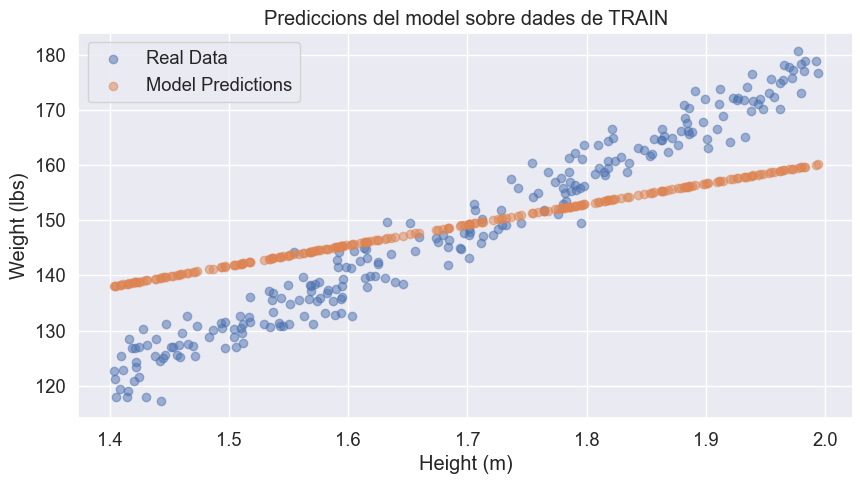

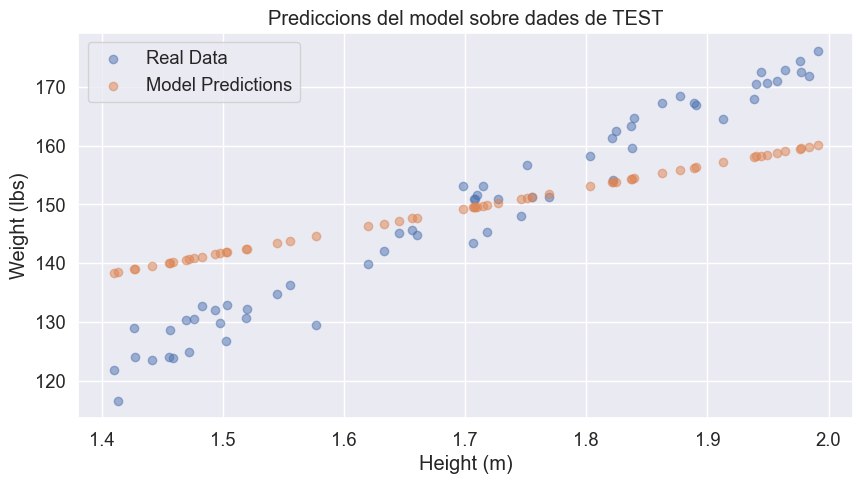

In [17]:

# TRAIN
x_train_np = x_train.values if hasattr(x_train, "values") else x_train
y_train_np = y_train.values if hasattr(y_train, "values") else y_train

y_pred_train = f.model(x_train_np).numpy().flatten()

plot_height_vs_weight(
    x_train_np.flatten(),
    y_train_np.flatten(),
    y_pred_train,
    "Model Predictions over TRAIN Data"
)

# TEST
x_test_np = x_test.values if hasattr(x_test, "values") else x_test
y_test_np = y_test.values if hasattr(y_test, "values") else y_test

y_pred_test = f.model(x_test_np).numpy().flatten()

plot_height_vs_weight(
    x_test_np.flatten(),
    y_test_np.flatten(),
    y_pred_test,
    "Model Predictions over TEST Data"
)


### Out Of Distribution (OOD) data

In [18]:
# Load OOD data
df_ood = pd.read_csv("data/height_weight_extrapolation.csv")

x_ood = df_ood[["height_m"]].astype(np.float32).values
y_ood = df_ood[["weight"]].astype(np.float32).values

ds_ood = tf.data.Dataset.from_tensor_slices((x_ood, y_ood)).batch(128)

print("OOD Sample loaded:", x_ood.shape, y_ood.shape)
df_ood.head()


Mostra OOD carregada: (400, 1) (400, 1)


,height_m,weight
0,1.00000,91.115400
1,1.00201,91.018210
2,1.00402,92.947840
3,1.00603,91.257070
4,1.00804,88.914444


In [19]:
# Baseline evaluation adopted function
def evaluate_dataset_baseline(dataset):
    rmse_metric = tf.keras.metrics.RootMeanSquaredError()
    sat_metric = tf.keras.metrics.Mean()

    for x_b, y_b in dataset:
        preds = f.model(x_b)
        rmse_metric.update_state(y_b, preds)

        sat = axioms(x_b, y_b)  
        sat_metric.update_state(sat)

    return {
        "rmse": float(rmse_metric.result().numpy()),
        "sat_reg": float(sat_metric.result().numpy())
    }



### OOD data results

In [20]:

results_ood = evaluate_dataset_baseline(ds_ood)

print("=== OOD Results ===")
print(f"RMSE: {results_ood['rmse']:.4f}")
print(f"Satisfacció regressió: {results_ood['sat_reg']:.4f}")

=== Resultats OOD ===
RMSE: 27.0991
Satisfacció regressió: 0.7466


#### Predicted vs Real value comparison

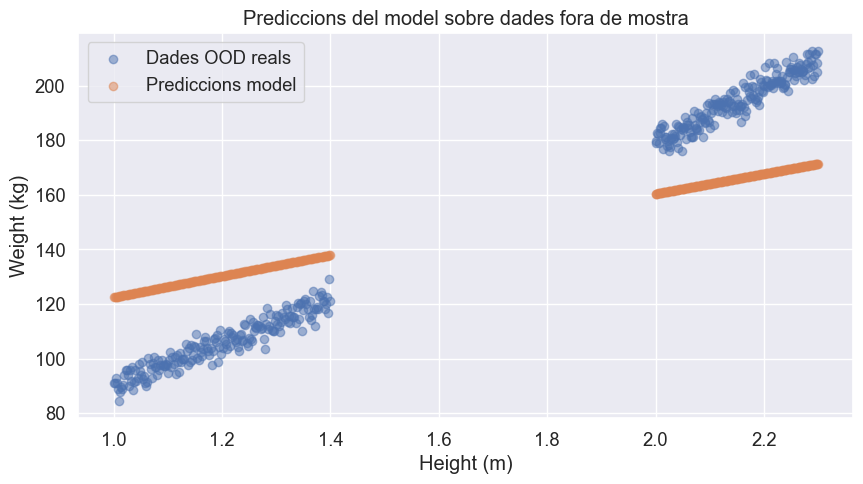

In [21]:
# Predictions OOD
y_pred_ood = f.model(x_ood).numpy().flatten()

plt.figure(figsize=(10,5))
plt.scatter(x_ood, y_ood, label="Real OOD data", alpha=0.5)
plt.scatter(x_ood, y_pred_ood, label="Model predictions", alpha=0.5)
plt.xlabel("Height (m)")
plt.ylabel("Weight (lb)")
plt.title("Model predictions over OOD data")
plt.legend()
plt.grid(True)
plt.show()


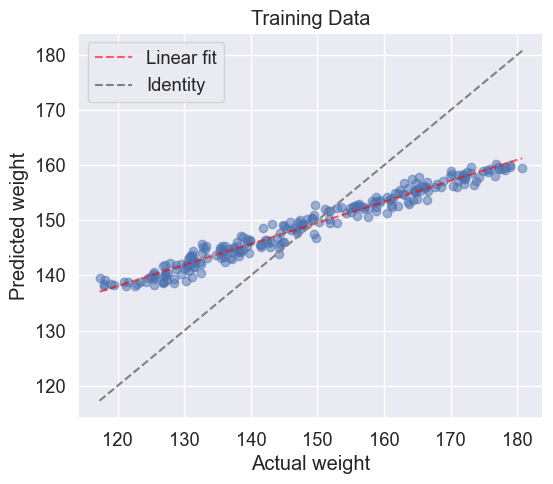

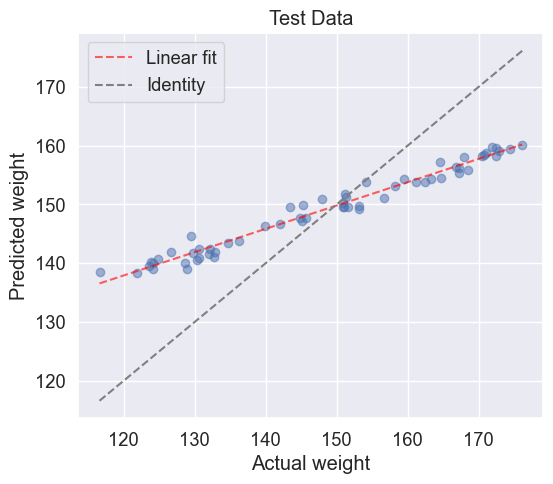

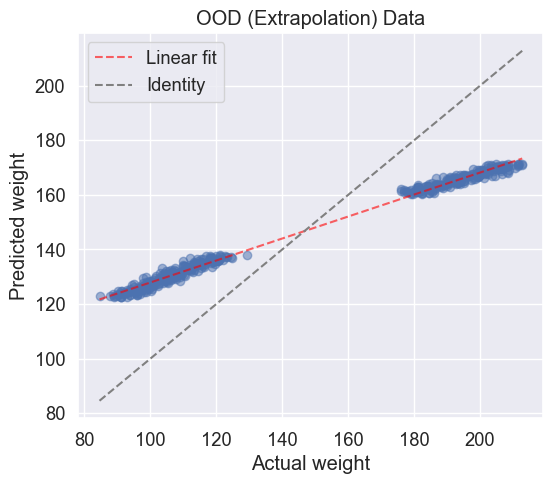

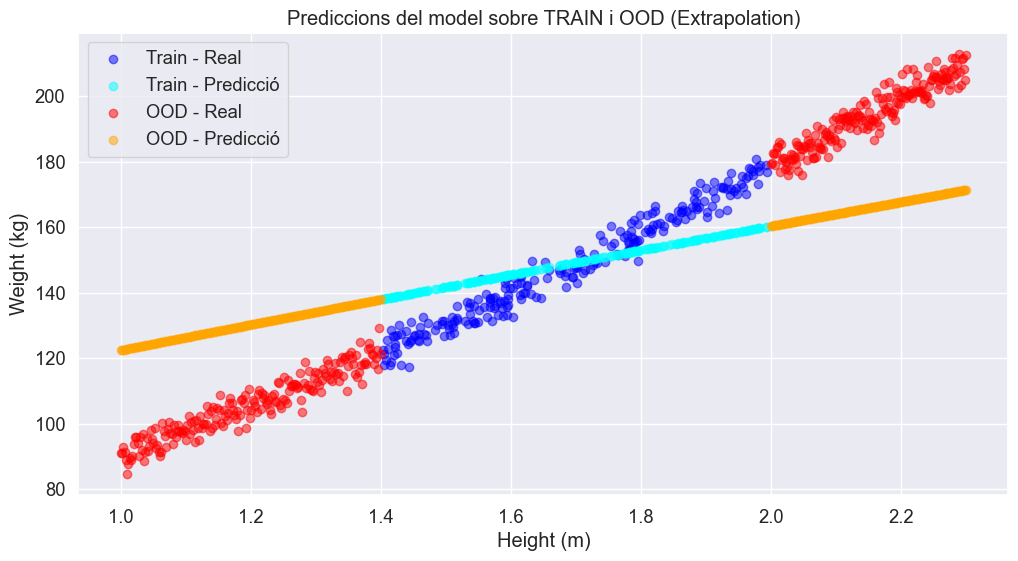

In [22]:

def plot_pred_vs_actual(y_true, y_pred, title):
    plt.figure(figsize=(6,5))
    plt.scatter(y_true, y_pred, alpha=0.5)

    # Lineal fit
    m, b = np.polyfit(y_true, y_pred, 1)
    xs = np.linspace(min(y_true), max(y_true), 100)
    plt.plot(xs, m*xs + b, color='red', linestyle='--', alpha=0.6, label="Linear fit")

    # Identity line 
    plt.plot(xs, xs, color='gray', linestyle='--', label="Identity")

    plt.xlabel("Actual weight")
    plt.ylabel("Predicted weight")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()



#   TRAIN
x_train_np = x_train.values if hasattr(x_train, "values") else x_train
y_train_np = y_train.values if hasattr(y_train, "values") else y_train

y_pred_train = f.model(x_train_np).numpy().flatten()

plot_pred_vs_actual(
    y_train_np.flatten(),
    y_pred_train,
    "Training Data"
)


#   TEST
x_test_np = x_test.values if hasattr(x_test, "values") else x_test
y_test_np = y_test.values if hasattr(y_test, "values") else y_test

y_pred_test = f.model(x_test_np).numpy().flatten()

plot_pred_vs_actual(
    y_test_np.flatten(),
    y_pred_test,
    "Test Data"
)


#   OOD
y_pred_ood = f.model(x_ood).numpy().flatten()

plot_pred_vs_actual(
    y_ood.flatten(),
    y_pred_ood,
    "OOD (Extrapolation) Data"
)


#   Combined TRAIN + OOD plot

plt.figure(figsize=(12,6))

# TRAIN: reals and predictions
plt.scatter(x_train_np, y_train_np, label="Train - Real", alpha=0.5, color="blue")
plt.scatter(x_train_np, y_pred_train, label="Train - Prediction", alpha=0.5, color="cyan")

# OOD: reals and predictions
plt.scatter(x_ood, y_ood, label="OOD - Real", alpha=0.5, color="red")
plt.scatter(x_ood, y_pred_ood, label="OOD - Prediction", alpha=0.5, color="orange")

plt.xlabel("Height (m)")
plt.ylabel("Weight (lb)")
plt.title("Model predictions over TRAIN and OOD (Extrapolation)")
plt.grid(True)
plt.legend()
plt.show()
